In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# A notebook to analyze backtesting results

This simple notebook is to be used to 
- visualize the spread between the theoretical price of an option and the price of the corresponding hedging portfolio,
- compute the tracking error for the hedging portfolio.
It takes as an input the json file containing the output data produced by the hedger.

## Set the path to the file to investigate

In [4]:
FILE = 'TestOutputs/Test_1_3.json' #enter correct path here

In [5]:
df = pd.read_json(FILE, convert_dates=['date'])
df.sort_values(by='date', inplace=True)
df.set_index('date', inplace=True)

## Plot the portfolio value against the theoretical price

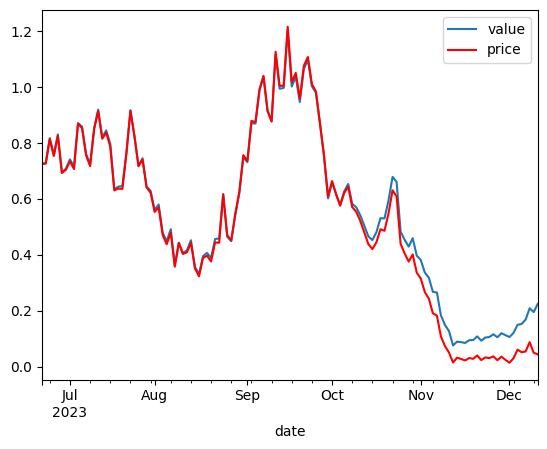

In [6]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
plt.show()

## Compute the PnL and tracking error

In [7]:
pnl = df['value'].iloc[-1] - df['price'].iloc[-1]
print(f'PnL: {pnl:.2f}')
tracking_error = (df['value'].iloc[-1] - df.price.iloc[-1])/df.price.iloc[0]
print(f'Tracking error: {tracking_error:.2%}')

PnL: 0.18
Tracking error: 24.91%


### Compute the cumulated transaction costs

In [8]:
df.head()

,value,price,PriceStdDev,Deltas,DeltaStdDev
date,,,,,
2023-06-22,0.725036,0.725036,0,[0.555562429687906],[0]
2023-06-23,0.728882,0.726189,0,[0.557175392944785],[0]
2023-06-26,0.817487,0.815050,0,[0.5943293152232321],[0]
2023-06-27,0.757540,0.753566,0,[0.570928698439444],[0]
2023-06-28,0.830899,0.826136,0,[0.6009878128941121],[0]


In [9]:
df['total_tc'] = df.transactionCosts.cumsum()

AttributeError: 'DataFrame' object has no attribute 'transactionCosts'

KeyError: 'total_tc'

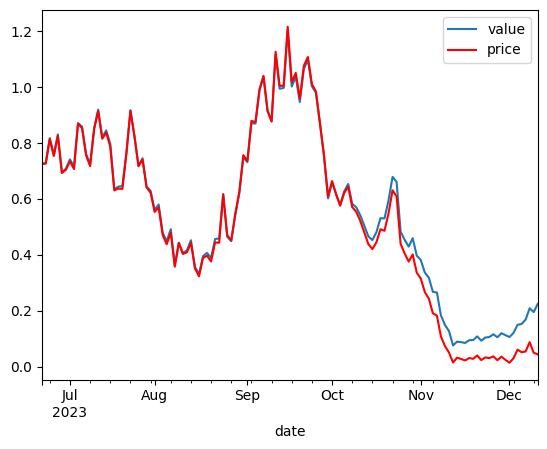

In [10]:
ax = plt.gca()
df.plot(y = 'value', ax = ax)
df.plot(y = 'price', color = 'red', ax = ax)
df.plot(y = 'total_tc', color = 'green', ax = ax)
plt.title('Value, Price and Total Transaction Costs')
plt.show()

In [ ]:
total_pnl = df['value'].iloc[-1] - df['price'].iloc[-1] - df['total_tc'].iloc[-1]
print(f'Total PnL after transaction costs: {total_pnl:.2f}')